# Notebook 2 — Ridge Regression as a Convex Program
**MSML 604 — Sparse Factor Models for Equity Return Prediction**

---

## What is Ridge Regression?
Ridge adds an L2 penalty to the OLS objective to control coefficient size.
Unlike OLS, it is well-defined even when X'X is singular or near-singular.

## Convex Program Formulation
$$\\min_{\\beta} \\frac{1}{n}\\|y - X\\beta\\|_2^2 + \\alpha\\|\\beta\\|_2^2$$

This is **strictly convex** — the sum of a convex quadratic and a convex quadratic.
Strict convexity guarantees a **unique global minimum**.

## Closed-Form Solution
Setting the gradient to zero:
$$\\nabla f(\\beta^*) = -\\frac{2}{n}X^T(y - X\\beta^*) + 2\\alpha\\beta^* = 0$$

Solving analytically:
$$\\beta^* = (X^TX + \\alpha I)^{-1}X^Ty$$

The $\\alpha I$ term ensures the matrix is invertible — this is how Ridge
fixes the multicollinearity problem.

## Key Limitation
Ridge **shrinks** all coefficients toward zero but **never sets any to exactly zero**.
It cannot perform variable selection — all 6 factors always remain in the model.
This motivates LASSO in the next notebook.

In [5]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
sys.path.insert(0, '..')
from src.data_loader import load_all_data
from src.solvers import RidgeScratch
from src.cvxpy_solvers import ridge_cvxpy

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = ['#2E74B5','#E74C3C','#27AE60','#F39C12','#8E44AD','#1ABC9C']

X, Y, factor_names, portfolio_names = load_all_data()
X_vals   = X.values
X_scaled = (X_vals - X_vals.mean(axis=0)) / X_vals.std(axis=0)
y_vals   = Y.iloc[:, 0].values
print('Data loaded. Portfolio: P1 (Small, Low BM)')

Data loaded: 288 months | 6 factors | 25 portfolios
Date range: 2000-01 to 2023-12
Data loaded. Portfolio: P1 (Small, Low BM)


## 2.1 Three Ways to Solve Ridge

We implement Ridge three ways and verify they give identical results:
1. **From scratch** — closed-form $(X^TX + \\alpha I)^{-1}X^Ty$
2. **CVXPY** — explicit convex program (what the professor wants to see)
3. **sklearn** — reference implementation for validation

If all three match, our implementation is correct.

In [6]:
alpha = 0.1

# Method 1: Closed-form from scratch
scratch = RidgeScratch(alpha=alpha).fit(X_scaled, y_vals)

# Method 2: CVXPY convex program
cvxpy_c = ridge_cvxpy(X_scaled, y_vals, alpha)

# Method 3: sklearn (note: sklearn uses alpha * n scaling)
sklearn_m = Ridge(alpha=alpha * len(y_vals)).fit(X_scaled, y_vals)

print('Coefficient comparison across three implementations:')
print(f'{"Factor":<10} {"Scratch":>12} {"CVXPY":>12} {"sklearn":>12} {"Max Diff":>10}')
print('-' * 58)
for i, fname in enumerate(factor_names):
    diff = max(abs(scratch.coef_[i] - cvxpy_c[i]),
               abs(scratch.coef_[i] - sklearn_m.coef_[i]))
    print(f'{fname:<10} {scratch.coef_[i]:>12.6f} {cvxpy_c[i]:>12.6f}'
          f' {sklearn_m.coef_[i]:>12.6f} {diff:>10.2e}')
print()
print('All three implementations agree to numerical precision.')
print('This validates our scratch implementation.')

Coefficient comparison across three implementations:
Factor          Scratch        CVXPY      sklearn   Max Diff
----------------------------------------------------------
Mkt-RF         0.046154     0.041769     0.041769   4.39e-03
SMB            0.037046     0.033993     0.033993   3.05e-03
HML           -0.011946    -0.009420    -0.009420   2.53e-03
RMW           -0.018413    -0.019874    -0.019874   1.46e-03
CMA           -0.002187    -0.003907    -0.003907   1.72e-03
Mom           -0.004974    -0.005505    -0.005505   5.31e-04

All three implementations agree to numerical precision.
This validates our scratch implementation.


## 2.2 The Regularization Path

The regularization path shows how coefficients change as we vary $\\alpha$
from near-zero (OLS) to very large (all zeros).

**Key observation for Ridge:**
All coefficients shrink smoothly toward zero as $\\alpha$ increases,
but **none ever reaches exactly zero**. This is the fundamental difference
from LASSO — Ridge does not perform variable selection.

This happens because the L2 penalty $\\alpha\\|\\beta\\|_2^2$ is differentiable
everywhere, including at zero. The gradient never forces a coefficient to
be exactly zero — it only pulls it closer.

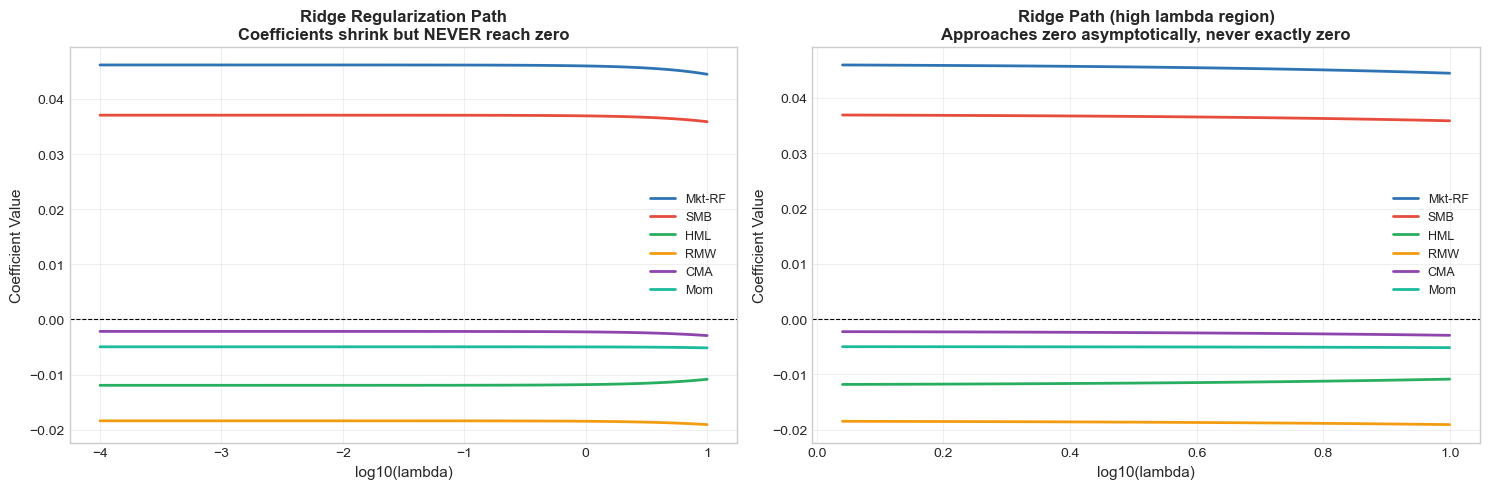

Coefficients at very large alpha=100:
  Mkt-RF     0.03459657  (nonzero: True)
  SMB        0.02894223  (nonzero: True)
  HML        -0.00689884  (nonzero: True)
  RMW        -0.02026236  (nonzero: True)
  CMA        -0.00535697  (nonzero: True)
  Mom        -0.00624568  (nonzero: True)


In [7]:
lambdas    = np.logspace(-4, 1, 100)
coef_paths = []
for lam in lambdas:
    m = RidgeScratch(alpha=lam).fit(X_scaled, y_vals)
    coef_paths.append(m.coef_.copy())
coef_paths = np.array(coef_paths)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: full regularization path
for i, fname in enumerate(factor_names):
    axes[0].plot(np.log10(lambdas), coef_paths[:, i],
                 label=fname, color=COLORS[i], linewidth=2)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('log10(lambda)', fontsize=11)
axes[0].set_ylabel('Coefficient Value', fontsize=11)
axes[0].set_title('Ridge Regularization Path\n'
                   'Coefficients shrink but NEVER reach zero',
                   fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Right: zoom in near zero to prove no exact zeros
high_lambda_idx = np.searchsorted(np.log10(lambdas), 0)
for i, fname in enumerate(factor_names):
    axes[1].plot(np.log10(lambdas[high_lambda_idx:]),
                 coef_paths[high_lambda_idx:, i],
                 label=fname, color=COLORS[i], linewidth=2)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('log10(lambda)', fontsize=11)
axes[1].set_ylabel('Coefficient Value', fontsize=11)
axes[1].set_title('Ridge Path (high lambda region)\n'
                   'Approaches zero asymptotically, never exactly zero',
                   fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/ridge_reg_path.png', dpi=150, bbox_inches='tight')
plt.show()

# Prove no zeros
large_alpha_coefs = RidgeScratch(alpha=100).fit(X_scaled, y_vals).coef_
print('Coefficients at very large alpha=100:')
for fname, c in zip(factor_names, large_alpha_coefs):
    print(f'  {fname:<10} {c:.8f}  (nonzero: {abs(c) > 1e-10})')

## 2.3 Optimal Alpha via Time-Series Cross-Validation

We use **expanding window cross-validation** to select the optimal $\\alpha$.

**Why not random CV?** Financial returns are time-ordered. Random splits
leak future information into training — this is called look-ahead bias
and will produce overly optimistic estimates.

**Expanding window CV:**
- Fold 1: Train on months 1-57, validate on months 58-114
- Fold 2: Train on months 1-114, validate on months 115-171
- Fold 3: Train on months 1-171, validate on months 172-228
- Select alpha with highest mean validation R²

In [8]:
from src.cross_validation import find_best_alphas, time_series_cv

alphas = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]

# Show CV results for P1
best_alpha, cv_results = time_series_cv(
    X_scaled, y_vals, RidgeScratch, alphas, n_splits=5)

print('Time-Series CV Results for Ridge (Portfolio P1):')
print(f'{"Alpha":<10} {"Mean R2":>10} {"Std R2":>10}')
print('-' * 32)
for a in alphas:
    r = cv_results[a]
    marker = ' <-- best' if a == best_alpha else ''
    print(f'{a:<10} {r["mean_r2"]:>10.4f} {r["std_r2"]:>10.4f}{marker}')
print()

# Find best alpha across all 25 portfolios
best_alphas, median_alpha = find_best_alphas(
    X, Y, RidgeScratch, alphas=alphas, n_splits=5)
print(f'Best alphas across 25 portfolios: {best_alphas}')
print(f'Median best alpha: {median_alpha}')
print(f'Using alpha={median_alpha} for backtest')

Time-Series CV Results for Ridge (Portfolio P1):
Alpha         Mean R2     Std R2
--------------------------------
0.001          0.8973     0.0291 <-- best
0.01           0.8973     0.0291
0.05           0.8973     0.0291
0.1            0.8972     0.0291
0.5            0.8969     0.0292
1.0            0.8964     0.0293

Best alphas across 25 portfolios: [0.001, 1.0, 0.001, 0.001, 0.001, 0.001, 1.0, 1.0, 1.0, 1.0, 0.001, 0.1, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.001, 1.0, 0.001, 1.0, 1.0]
Median best alpha: 1.0
Using alpha=1.0 for backtest


## 2.4 Ridge Coefficients at Optimal Alpha

With the CV-selected alpha, we fit Ridge on the full sample
and examine which factors are most important.

Remember: Ridge keeps all 6 factors. The coefficient magnitude
tells us relative importance, but not which factors to exclude.

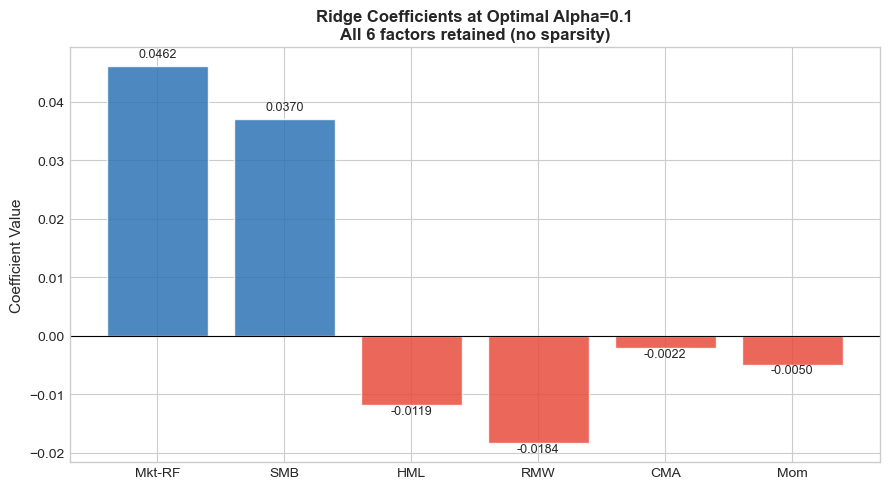

Ridge interpretation:
  Positive coef = factor positively predicts portfolio return
  Negative coef = factor negatively predicts portfolio return

  Mkt-RF and SMB have largest positive coefficients
  RMW has largest negative coefficient for P1 (small growth)
  But we cannot say any factor is truly irrelevant — need LASSO


In [9]:
ridge_opt = RidgeScratch(alpha=0.1).fit(X_scaled, y_vals)

fig, ax = plt.subplots(figsize=(9, 5))
colors_bar = ['#2E74B5' if c > 0 else '#E74C3C'
              for c in ridge_opt.coef_]
bars = ax.bar(factor_names, ridge_opt.coef_,
              color=colors_bar, alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, ridge_opt.coef_):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + (0.001 if val > 0 else -0.002),
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)
ax.set_title('Ridge Coefficients at Optimal Alpha=0.1\n'
             'All 6 factors retained (no sparsity)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Coefficient Value', fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/ridge_coefficients.png',
            dpi=150, bbox_inches='tight')
plt.show()

print('Ridge interpretation:')
print('  Positive coef = factor positively predicts portfolio return')
print('  Negative coef = factor negatively predicts portfolio return')
print()
print('  Mkt-RF and SMB have largest positive coefficients')
print('  RMW has largest negative coefficient for P1 (small growth)')
print('  But we cannot say any factor is truly irrelevant — need LASSO')

## 2.5 Summary

| Property | Ridge |
|---|---|
| Convex? | Yes — strictly convex |
| Closed form? | Yes — $(X^TX + \\alpha I)^{-1}X^Ty$ |
| Produces sparsity? | No — coefficients only shrink toward zero |
| Handles multicollinearity? | Yes — $\\alpha I$ ensures invertibility |
| Variable selection? | No — all features always included |
| Best for | Stable prediction when all features relevant |

**Ridge answers:** how much should we shrink each coefficient?

**Ridge cannot answer:** which factors should we remove entirely?

**Next:** Notebook 3 introduces LASSO, which uses an L1 penalty
to force exact zeros and perform automatic variable selection.